In [1]:
%matplotlib notebook

import numpy as np
from matplotlib import pyplot as plt

from mmkin import *
from scipy import optimize

In [2]:
# choose the data to analyze

mutants = ['wt', 'N214A', 'Q256A', 'S284A']
mutant_colors  = ['k', 'b', 'g', 'orange']

ks_s = [
        KineticsSeries('./wt/wt.yaml', corrections='./config.yaml', prefix='./wt'),
        KineticsSeries('./N214A/n214a.yaml', corrections='./config.yaml', prefix='./N214A'),
        KineticsSeries('./Q256A/q256a.yaml', corrections='./config.yaml', prefix='./Q256A'),
        KineticsSeries('./S284A/s284a.yaml', corrections='./config.yaml', prefix='./S284A'),
       ]

#    ks = KineticsSeries('./wt_dmso/wt_dmso.yaml', corrections='./config.yaml', prefix='./wt_dmso')

ps = [5.0, 10.0, 20.0, 40.0, 80.0, 160.0]
ss = np.array([160.0, 80.0, 40.0, 20.0, 10.0, 5.0])

Loading: 210401_2µM_MproWT.csv...
 ... excluded
Loading: 210401_buffer_200µM_MproWT.csv...
 ... excluded
Loading: 210413_02_002µM_MproWT.csv...
 ... excluded
Loading: 210413_buffer_2µM_MproWT.csv...
 ... excluded
Loading: 210420_20µM_MproWT.csv...
 ... excluded
Loading: 210420_10µM_MproWT.csv...
 ... excluded
Loading: 210420_5_and_2µM_MproWT.csv...
 ... excluded
Loading: 210430_20_10_5_and_2µM_MproWT.csv...
Loading: 210430_buffer_160_80_and_40µM_MproWT.csv...
 ... excluding E=160.00 / S=160.00
Loading: 210507_buffer_20µM_MproWT_N_Q_S.csv...
 ... excluded
Loading: 210507_10µM_MproWT_N_Q_S.csv...
 ... excluded
Loading: 210414_20_2_02_002µM_MproN214A.csv...
 ... excluded
Loading: 210421_20_and_10_µM_MproN214A.csv...
 ... excluded
Loading: 210421_5_and_2_µM_MproN214A.csv...
 ... excluded
Loading: 210427_buffer_160_and_80µM_MproN214A.csv...
Loading: 210427_buffer_160_and_80µM_MproN214A_2.csv...
Loading: 210427_40_20_and_10µM_MproN214A.csv...
 ... excluding E=20.00 / S=20.00
 ... excluding E

In [3]:
n_p = len(ps)
n_s = len(ss)
print(n_p, n_s)

for ks in ks_s:
    ks.fit_v0(r2_threshold=0.0)

6 6


N214A


<IPython.core.display.Javascript object>


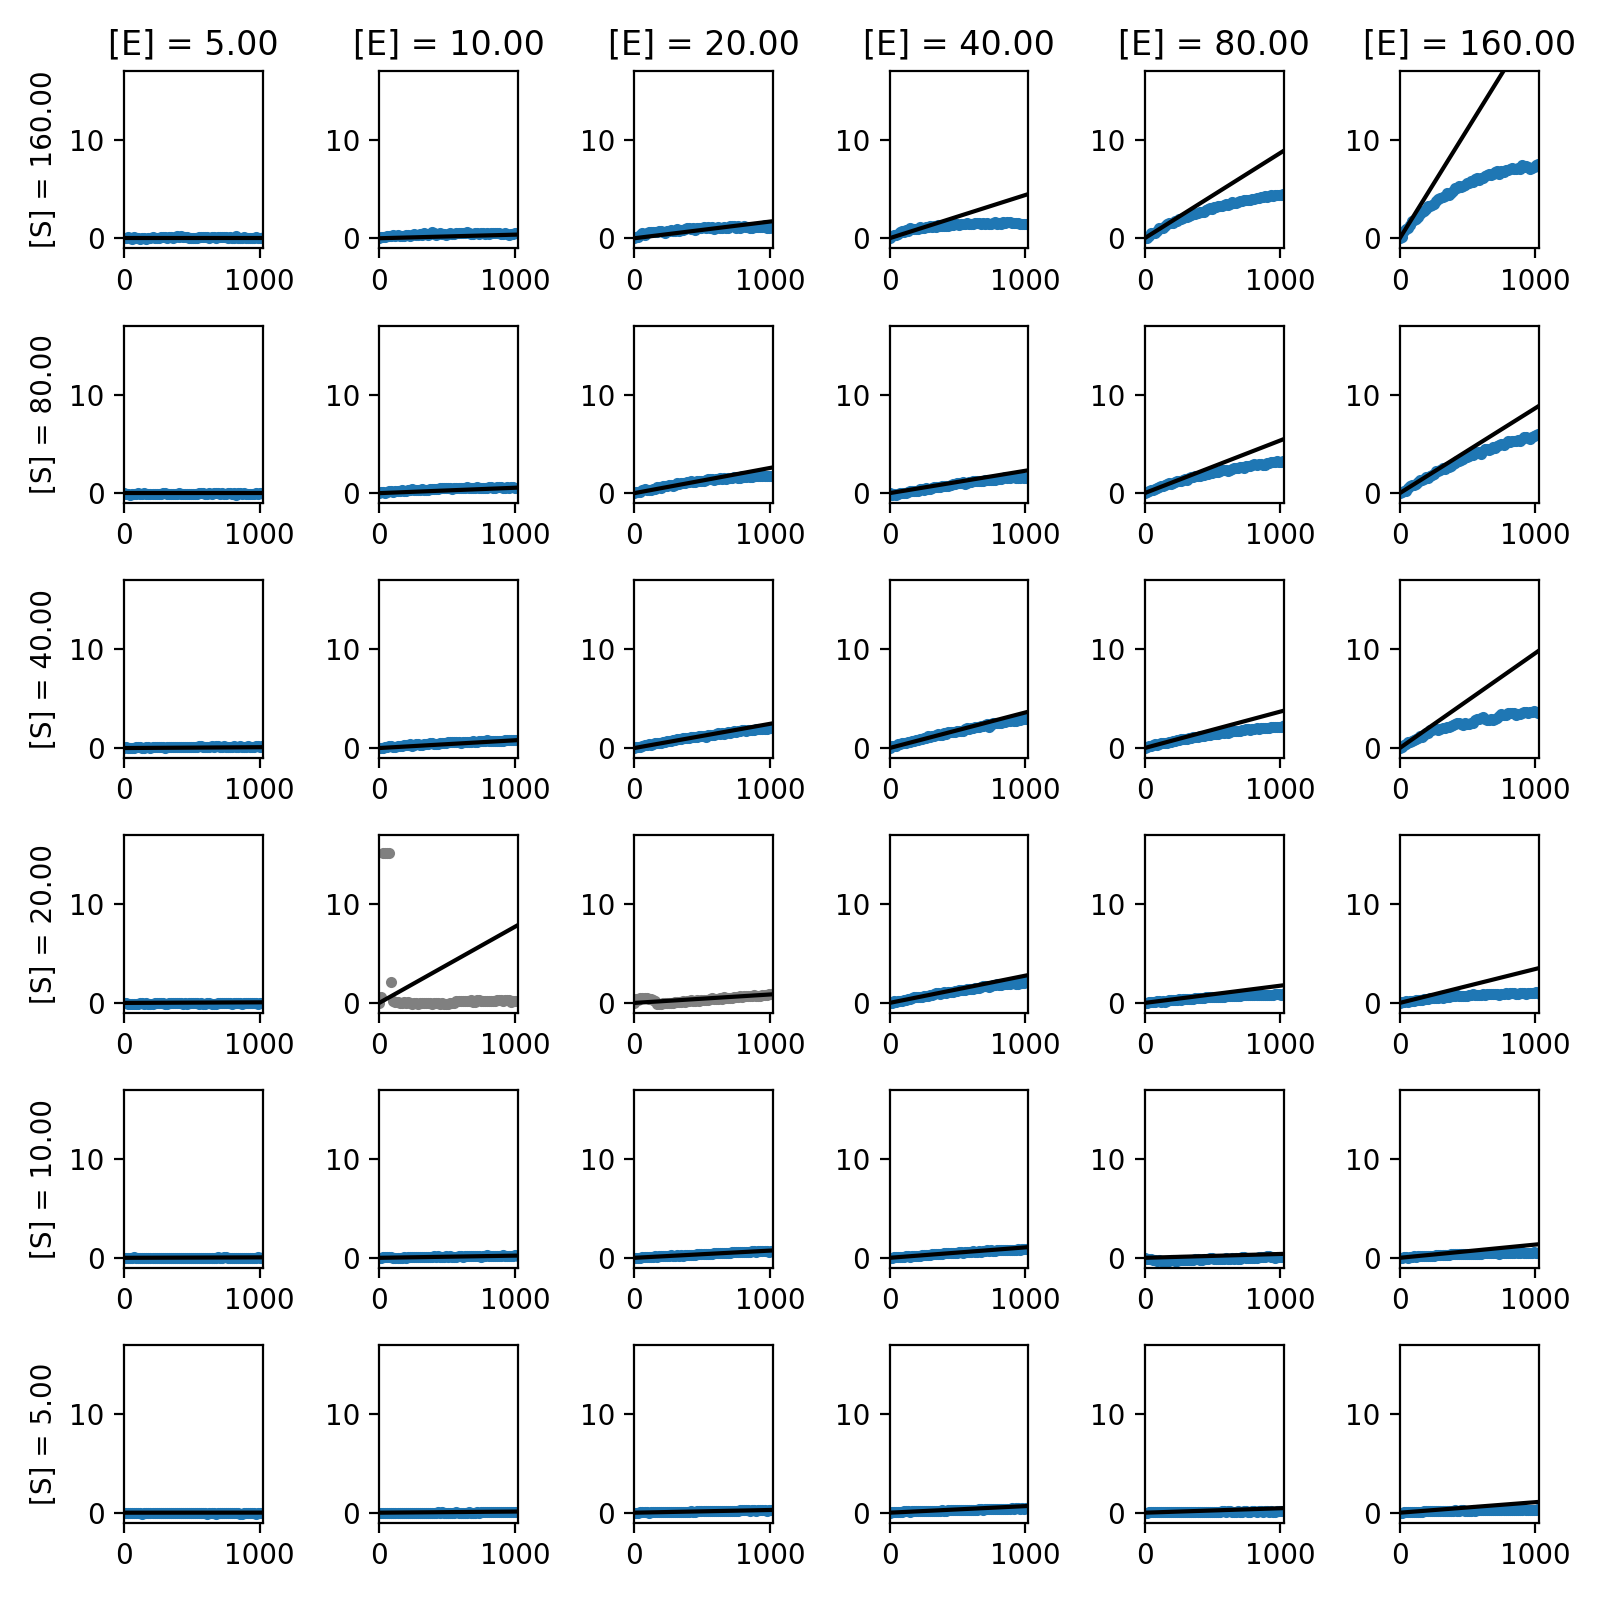

excluded: p=10.000000 / s=20.000000
excluded: p=20.000000 / s=20.000000


In [4]:
# choose one mutant and inspect

mutant_index = 1
mutant = mutants[mutant_index]
print(mutant)

ks = ks_s[mutant_index]

fig, axes = plt.subplots(n_s, n_p, figsize=(8,8))

for i_p,p in enumerate(ps):
    for i_s,s in enumerate(ss):
        
        v0_set = []
        
        for entry in ks.get(p, s):
            
            if i_s == 0:
                axes[i_s, i_p].set_title('[E] = %.2f' % p)
            if i_p == 0:
                axes[i_s, i_p].set_ylabel('[S] = %.2f' % s)
                
            axes[i_s, i_p].set_xlim([0, 1024])
            axes[i_s, i_p].set_ylim([-1, 17])
            
            if entry['exclude']:
                axes[i_s, i_p].plot(t, entry['timeseries'], '.', color='gray')
                axes[i_s, i_p].plot(t, entry['v0'] * t, color='k', lw=1.5)
                print('excluded: p=%f / s=%f' % (p, s))
                continue
            
            t = entry['dt'] * np.arange(len(entry['timeseries']))
            axes[i_s, i_p].plot(t, entry['timeseries'], '.')
            axes[i_s, i_p].plot(t, entry['v0'] * t, color='k', lw=1.5)
            
plt.tight_layout()
plt.savefig('figures/%s_traces.pdf' % mutant)
plt.show()

<IPython.core.display.Javascript object>


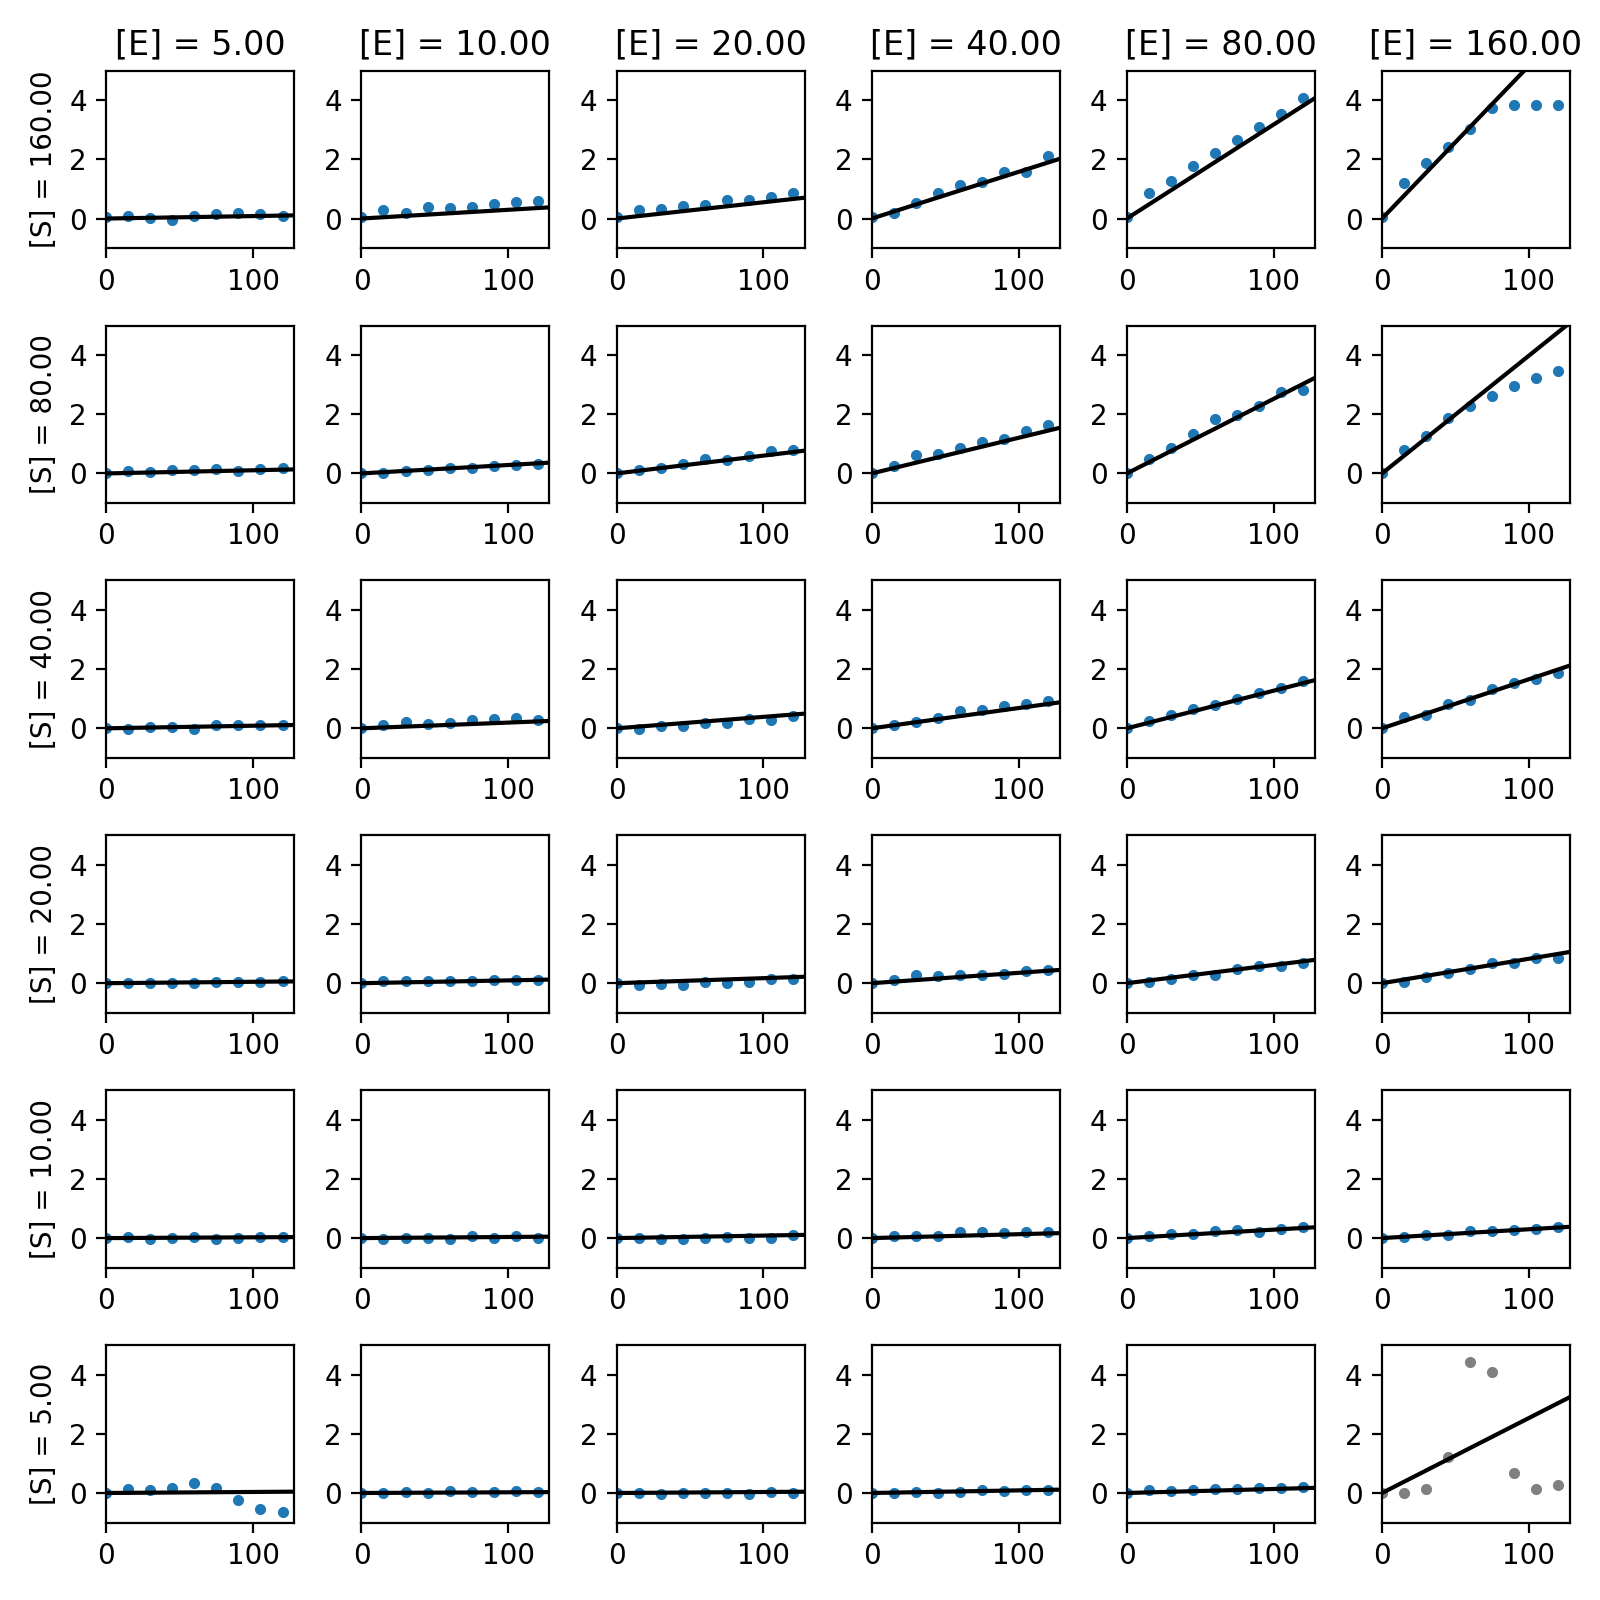

v0, v0err / 8.35e-04 1.91e-05
v0, v0err / 1.06e-03 1.23e-05
v0, v0err / 8.79e-04 8.54e-06
v0, v0err / 4.77e-04 5.04e-06
v0, v0err / 2.63e-04 5.76e-06
v0, v0err / 3.46e-04 9.14e-05
v0, v0err / 2.95e-03 5.26e-05
v0, v0err / 2.85e-03 2.74e-05
v0, v0err / 1.94e-03 1.83e-05
v0, v0err / 9.52e-04 1.25e-05
v0, v0err / 3.76e-04 4.72e-06
v0, v0err / 2.34e-04 8.65e-06
v0, v0err / 5.50e-03 9.72e-05
v0, v0err / 6.02e-03 8.12e-05
v0, v0err / 3.87e-03 5.11e-05
v0, v0err / 1.70e-03 4.35e-05
v0, v0err / 8.46e-04 3.74e-05
v0, v0err / 3.32e-04 8.43e-06
v0, v0err / 1.58e-02 3.69e-04
v0, v0err / 1.20e-02 2.58e-04
v0, v0err / 6.86e-03 2.26e-04
v0, v0err / 3.51e-03 1.73e-04
v0, v0err / 1.31e-03 1.08e-04
v0, v0err / 8.80e-04 9.19e-05
v0, v0err / 3.18e-02 1.15e-03
v0, v0err / 2.52e-02 1.09e-03
v0, v0err / 1.27e-02 2.18e-04
v0, v0err / 6.17e-03 5.47e-04
v0, v0err / 2.85e-03 1.21e-04
v0, v0err / 1.35e-03 2.59e-04
v0, v0err / 5.16e-02 6.47e-03
v0, v0err / 3.98e-02 2.89e-03
v0, v0err / 1.66e-02 2.73e-03
v0, v0err 

In [19]:
fig, axes = plt.subplots(n_s, n_p, figsize=(8,8))

for i_p,p in enumerate(ps):
    for i_s,s in enumerate(ss):
        
        v0_set = []
        
        for entry in ks.get(p, s):
            
            if i_s == 0:
                axes[i_s, i_p].set_title('[E] = %.2f' % p)
            if i_p == 0:
                axes[i_s, i_p].set_ylabel('[S] = %.2f' % s)
                
            axes[i_s, i_p].set_xlim([0, 128])
            axes[i_s, i_p].set_ylim([-1, 5])
            
            #print('v0, v0err / %.2e %.2e' % (entry['v0'], entry['stderr_v0']))
            
            if entry['exclude']:
                axes[i_s, i_p].plot(t, entry['timeseries'], '.', color='gray')
                axes[i_s, i_p].plot(t, entry['v0'] * t, color='k', lw=1.5)
                print('excluded: p=%f / s=%f' % (p, s))
                continue
            
            t = entry['dt'] * np.arange(len(entry['timeseries']))
            axes[i_s, i_p].plot(t, entry['timeseries'], '.')
            axes[i_s, i_p].plot(t, entry['v0'] * t, color='k', lw=1.5)
            
plt.tight_layout()
plt.savefig('figures/%s_traces_zoom.pdf' % mutant)
plt.show()

## Fit all mutants

In [6]:
# capture the k_cat, K_m for each mutant
# (mutants, protein_concentrations, conc/k_cat/k_cat_err/K_m/K_m_err)

kinetic_params = np.zeros([4, n_p, 5])

<IPython.core.display.Javascript object>


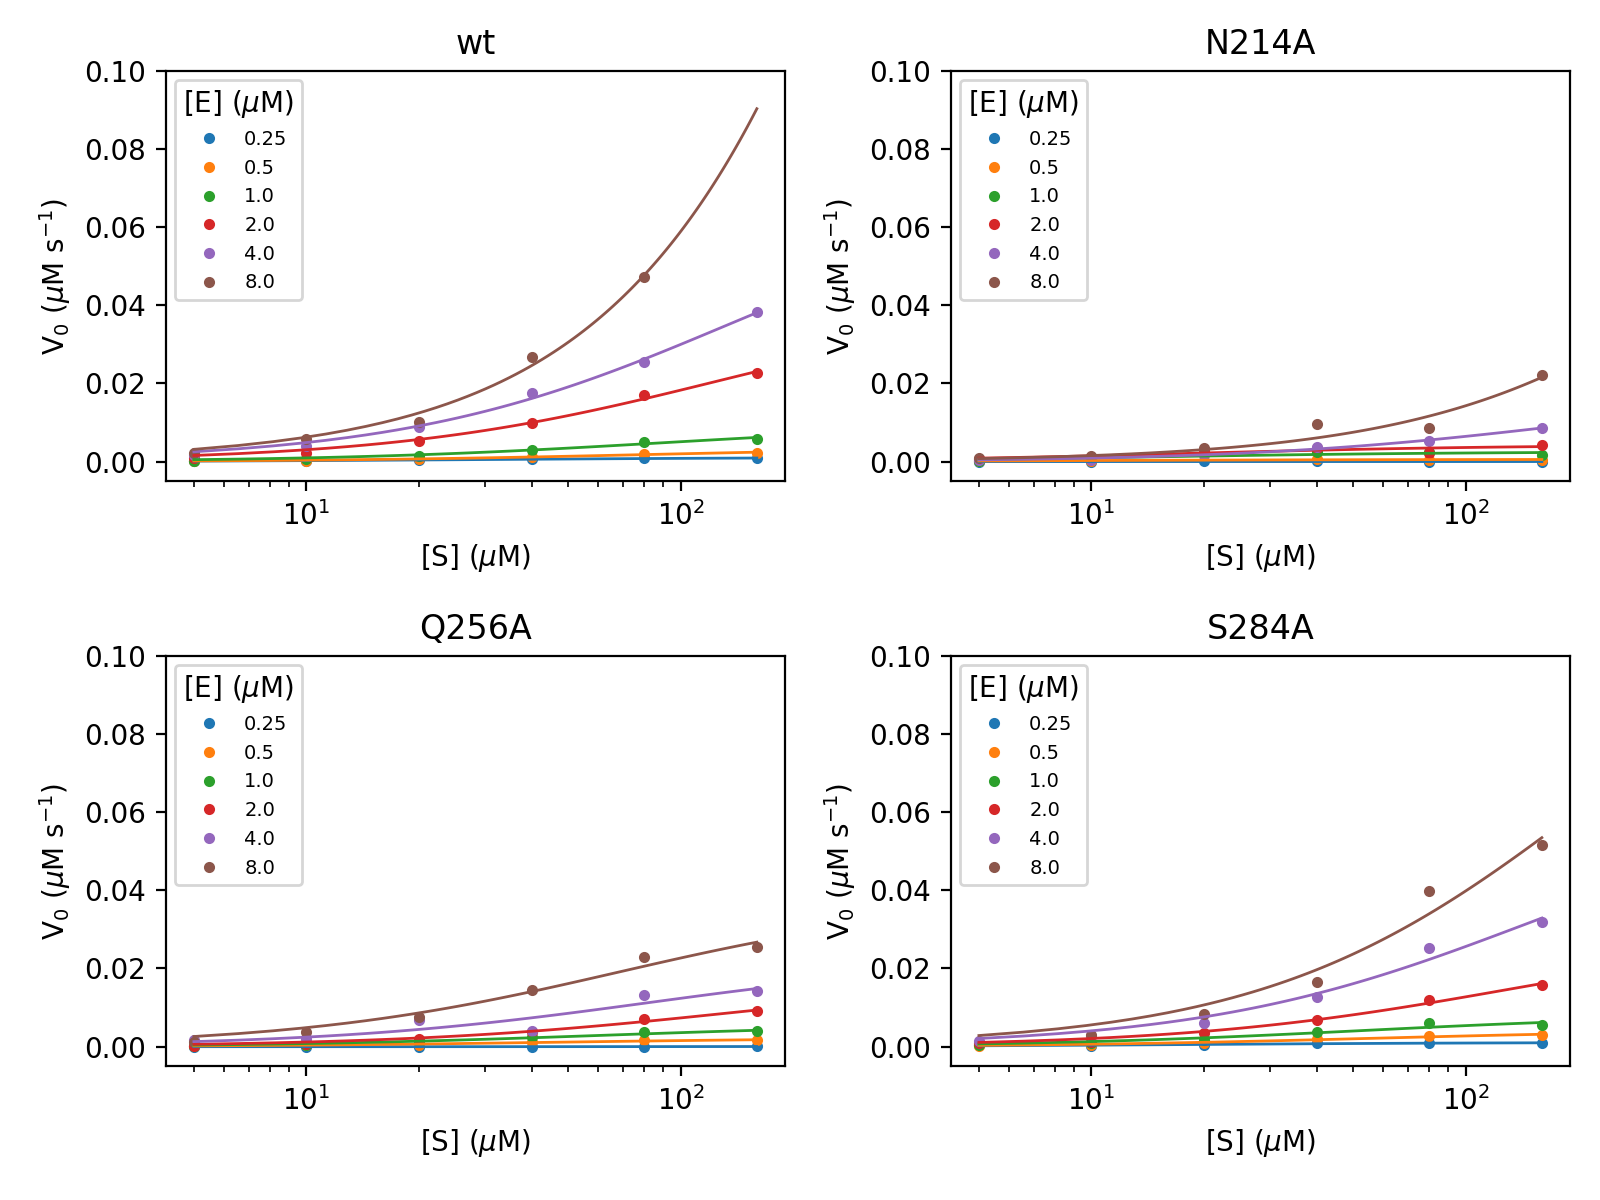


---wt---

[E]	k_cat		err		K_m		err
---	-----		---		---		---
0.25	4.43e-03	6.39e-04	3.03e+01	1.23e+01
0.50	7.38e-03	1.15e-03	8.29e+01	2.65e+01
1.00	9.66e-03	1.71e-03	8.92e+01	3.17e+01
2.00	2.05e-02	2.06e-03	1.24e+02	2.25e+01
4.00	1.74e-02	1.58e-03	1.32e+02	2.12e+01
8.00	1.03e-01	2.31e-01	1.31e+03	3.07e+03

---N214A---

[E]	k_cat		err		K_m		err
---	-----		---		---		---
0.25	1.41e-04	9.74e-05	1.14e+00	9.67e+00
0.50	1.20e-03	3.99e-04	9.99e+00	1.41e+01
1.00	2.57e-03	6.78e-04	1.58e+01	1.58e+01
2.00	2.16e-03	4.87e-04	1.88e+01	1.39e+01
4.00	4.81e-03	9.43e-04	1.97e+02	6.04e+01
8.00	1.80e-02	3.84e-02	9.08e+02	2.21e+03

---Q256A---

[E]	k_cat		err		K_m		err
---	-----		---		---		---
0.25	5.35e+03	nan	4.88e+09	nan
0.50	4.61e-03	6.65e-04	4.76e+01	1.69e+01
1.00	5.82e-03	9.57e-04	6.20e+01	2.30e+01
2.00	8.64e-03	1.30e-03	1.35e+02	3.56e+01
4.00	5.62e-03	2.06e-03	8.18e+01	6.18e+01
8.00	4.77e-03	5.87e-04	6.82e+01	1.84e+01

---S284A---

[E]	k_cat		err		K_m		err
---	-----		---		---		---
0.25	4.42e-03	7.48e

/Users/TJ/Desktop/mprodata/kinetics/mmkin.py:352: RuntimeWarning: invalid value encountered in sqrt
  perr = np.sqrt(np.diag(pcov))


In [23]:
fig, axes = plt.subplots(2, 2, figsize=(8,6))

for im, m in enumerate(mutants):
    
    ks = ks_s[im]
    
    print('\n---' + m + '---\n')

    ax = axes[ im//2, im%2 ]
    ax.set_title(m)
    
    for p in ps:
        s0s, _, v0s, v0errs = ks.get_set_v0s([p], ss)
        ax.plot(s0s, v0s, '.')

    ax.legend( np.array(ps) / 20.0, title='[E] ($\mu$M)', fontsize=7, loc=2)

    # fit
    print('[E]\tk_cat\t\terr\t\tK_m\t\terr')
    print('---\t-----\t\t---\t\t---\t\t---')

    ax.set_prop_cycle(None)
    for i,p in enumerate(ps):

        s0s, _, v0s, v0errs = ks.get_set_v0s([p], ss)

        (k_cat, K_m), perr = fit_mm(v0s, s0s, p / 20.0, v0errs=None)

        print('%.2f\t%.2e\t%.2e\t%.2e\t%.2e' % (p / 20.0, k_cat, perr[0], K_m, perr[1]))
        kinetic_params[im,i,:] = np.array([p, k_cat, perr[0], K_m, perr[1]])

        S = np.linspace(ss.min(), ss.max(), 100)
        V_fit = mm( p / 20.0, S, k_cat, K_m)
        ax.plot(S, V_fit, lw=1)
    
    ax.set_xscale('log')
    ax.set_ylim([-0.005, 0.1])
    ax.set_xlabel('[S] ($\mu$M)')
    ax.set_ylabel('V$_0$ ($\mu$M s$^{-1}$)')
    
plt.tight_layout()
plt.savefig('figures/mm.pdf')
plt.show()

<IPython.core.display.Javascript object>


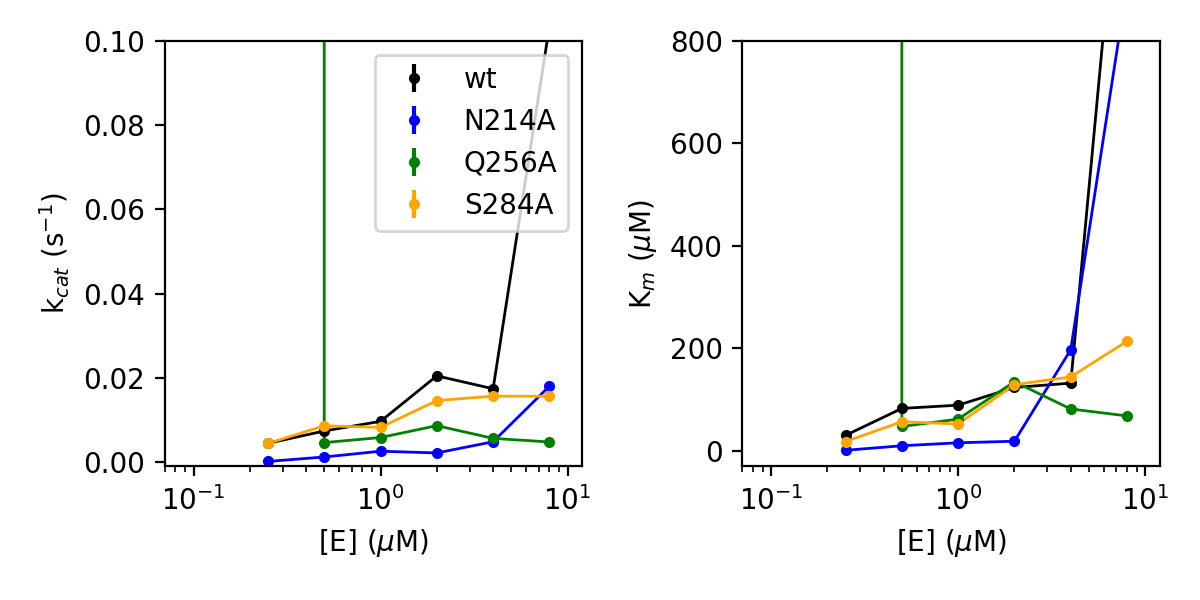

In [21]:
# by fiat, set Q256A E=0.1,0.25 values to zero (unmeasurable)
# -----

plt.figure(figsize=(6,3))

plt.subplot(121)
for im, m in enumerate(mutants):
    plt.errorbar(kinetic_params[im,:,0] / 20.0, kinetic_params[im,:,1], fmt='.',
                 yerr=0.0, #kinetic_params[im,:,2],
                 color=mutant_colors[im])
    plt.plot(kinetic_params[im,:,0] / 20.0, kinetic_params[im,:,1], 
             '-', color=mutant_colors[im], lw=1, label='_nolegend_')
plt.xlabel('[E] ($\mu$M)')
plt.ylabel('k$_{cat}$ (s$^{-1}$)')
plt.xscale('log')
plt.ylim([-0.001, 0.1])
plt.xlim([0.07, 12.0])
plt.legend(mutants)

plt.subplot(122)
for im, m in enumerate(mutants):
    plt.errorbar(kinetic_params[im,:,0] / 20.0, kinetic_params[im,:,3], fmt='.',
                 yerr=0.0, #kinetic_params[im,:,4],
                 color=mutant_colors[im])
    plt.plot(kinetic_params[im,:,0] / 20.0, kinetic_params[im,:,3], 
             '-', color=mutant_colors[im], lw=1, label='_nolegend_')
plt.xlabel('[E] ($\mu$M)')
plt.ylabel('K$_m$ ($\mu$M)')
plt.xscale('log')
plt.ylim([-30, 800])
plt.xlim([0.07, 12.0])
#plt.legend(mutants)

plt.tight_layout()
plt.savefig('figures/mm_parameters.pdf')
plt.show()

<IPython.core.display.Javascript object>


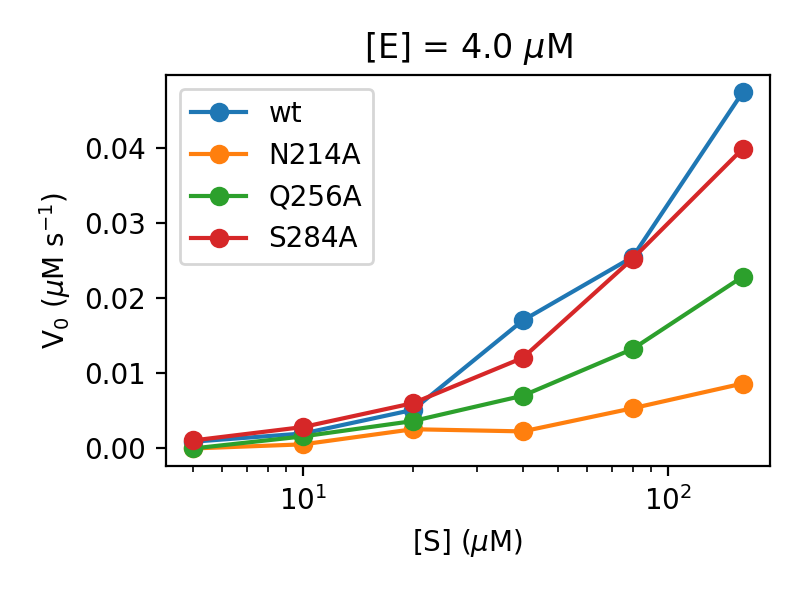

In [16]:
E_conc = 80.0

plt.figure(figsize=(4,3))
plt.title('[E] = %.1f $\mu$M' % (E_conc/20.0,))

for im, m in enumerate(mutants):
    
    ks = ks_s[im]

    for j,s in enumerate([E_conc]):
        _, p0s, v0s, v0errs = ks.get_set_v0s(ps, [s])
        plt.plot(p0s, v0s, '-o')

plt.legend(mutants)
plt.xlabel('[S] ($\mu$M)')
plt.ylabel('V$_0$ ($\mu$M s$^{-1}$)')
plt.xscale('log')

plt.tight_layout()
plt.savefig('figures/v0_vs_subs_conc.pdf')
plt.show()